In [2]:
#!pip install -r requirements.txt

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import holidays
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import itertools
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Carregamento dos dados e análise inicial

- Os dados foram obtidos através da plataforma da Agência Europeia do Meio Ambiente, contendo medições diárias de material particulado (PM) em Lisboa, de 2018 a 2023.
- O arquivo original foi obtido no formato Parquet, contendo 2.190 registros não nulos distribuídos em 11 colunas.


In [3]:
from google.colab import files
uploaded = files.upload()

Saving SPO-PT03082_00005_100.parquet to SPO-PT03082_00005_100.parquet


In [4]:
df = pd.read_parquet('/content/SPO-PT03082_00005_100.parquet')

In [5]:
df.head()

,Samplingpoint,Pollutant,Start,End,Value,Unit,AggType,Validity,Verification,ResultTime,DataCapture,FkObservationLog
0,PT/SPO-PT03082_00005_100,5,2018-01-01,2018-01-02,0E-18,ug.m-3,day,-1,1,2019-01-01 01:00:00,None,40e89b5f-9ee1-4885-a630-5634b7a141c1
1,PT/SPO-PT03082_00005_100,5,2018-01-02,2018-01-03,0E-18,ug.m-3,day,-1,1,2019-01-01 01:00:00,None,40e89b5f-9ee1-4885-a630-5634b7a141c1
2,PT/SPO-PT03082_00005_100,5,2018-01-03,2018-01-04,0E-18,ug.m-3,day,-1,1,2019-01-01 01:00:00,None,40e89b5f-9ee1-4885-a630-5634b7a141c1
3,PT/SPO-PT03082_00005_100,5,2018-01-04,2018-01-05,0E-18,ug.m-3,day,-1,1,2019-01-01 01:00:00,None,40e89b5f-9ee1-4885-a630-5634b7a141c1
4,PT/SPO-PT03082_00005_100,5,2018-01-05,2018-01-06,0E-18,ug.m-3,day,-1,1,2019-01-01 01:00:00,None,40e89b5f-9ee1-4885-a630-5634b7a141c1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Samplingpoint     2190 non-null   object        
 1   Pollutant         2190 non-null   int32         
 2   Start             2190 non-null   datetime64[ns]
 3   End               2190 non-null   datetime64[ns]
 4   Value             2190 non-null   object        
 5   Unit              2190 non-null   object        
 6   AggType           2190 non-null   object        
 7   Validity          2190 non-null   int32         
 8   Verification      2190 non-null   int32         
 9   ResultTime        2190 non-null   datetime64[ns]
 10  DataCapture       0 non-null      object        
 11  FkObservationLog  2190 non-null   object        
dtypes: datetime64[ns](3), int32(3), object(6)
memory usage: 179.8+ KB


In [7]:
df.Value.value_counts()

,count
Value,
0E-18,1342
13.800000000000000000,14
12.200000000000000000,11
16.000000000000000000,10
11.400000000000000000,10
...,...
28.400000000000000000,1
33.000000000000000000,1
32.800000000000000000,1


In [8]:
df.End.max()

Timestamp('2023-12-31 00:00:00')

In [9]:
# Converter coluna de datas
df = df[['Start', 'Value']]
df['Start'] = pd.to_datetime(df['Start'])
df.set_index('Start', inplace=True)
df = df.sort_index()
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

train = df[:'2022-12-31']
test = df['2023-01-01':]

<ipython-input-9-3812061744>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Start'] = pd.to_datetime(df['Start'])


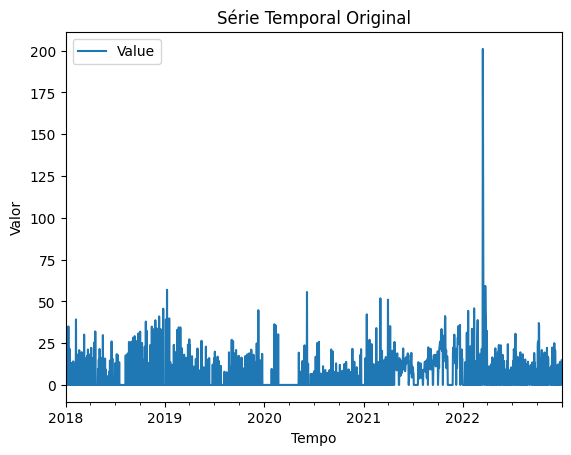

In [10]:
# Plot inicial
train.plot()
plt.title('Série Temporal Original')
plt.ylabel('Valor')
plt.xlabel('Tempo')
plt.show()

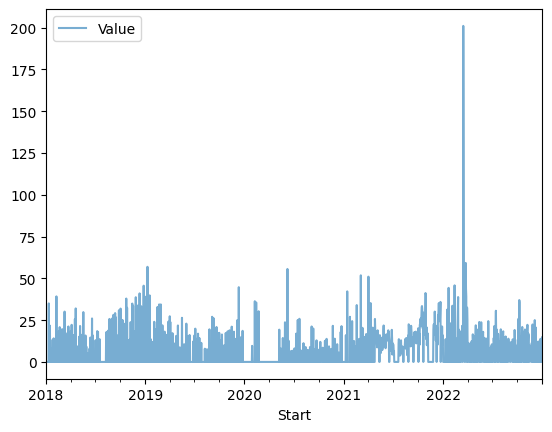

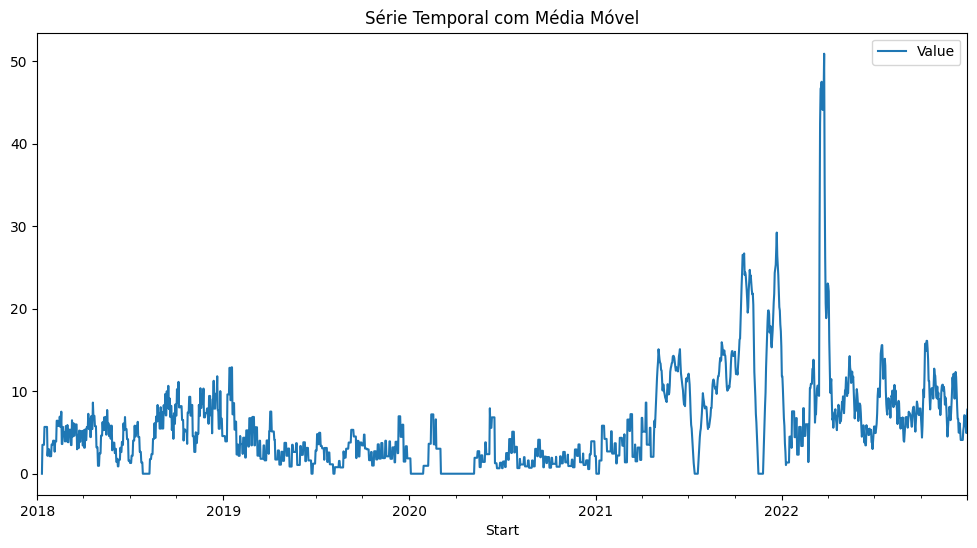

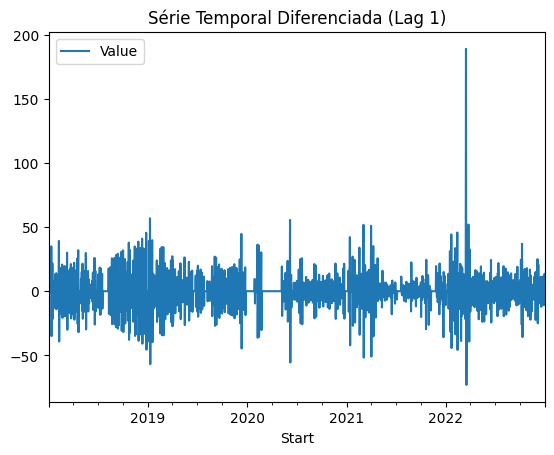

/usr/local/lib/python3.11/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


In [11]:
# Rolling window
rolling = train.rolling(window=10).mean()

train.plot(label='Original', alpha=0.6)
rolling.plot(label='Rolling mean (10)', figsize=(12, 6))
plt.title('Série Temporal com Média Móvel')
plt.legend()
plt.show()

# Diferenciação
train_diff = train.diff().dropna()

train_diff.plot()
plt.title('Série Temporal Diferenciada (Lag 1)')
plt.show()

# Transformação logarítmica (para estabilizar variância)
train_log = np.log(train)

In [12]:
train_zeros = train[train['Value'] == 0]
train_zeros

,Value
Start,
2018-01-01,0.0
2018-01-02,0.0
2018-01-03,0.0
2018-01-04,0.0
2018-01-05,0.0
...,...
2022-12-21,0.0
2022-12-22,0.0
2022-12-27,0.0


In [13]:
print(train['Value'].describe())

count    1826.000000
mean        5.748795
std        10.829517
min         0.000000
25%         0.000000
50%         0.000000
75%        10.575000
max       201.000000
Name: Value, dtype: float64


<Axes: xlabel='Value'>

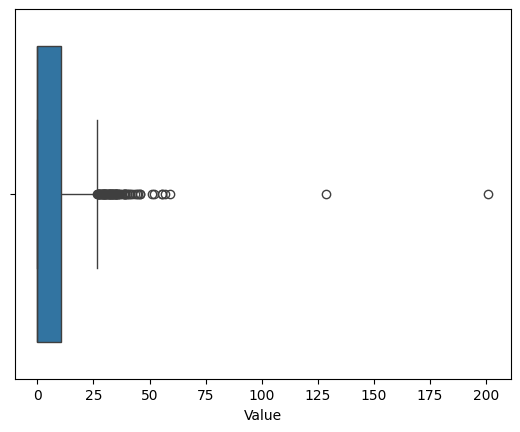

In [14]:
import seaborn as sns
sns.boxplot(x=train['Value'])  # para detectar outliers

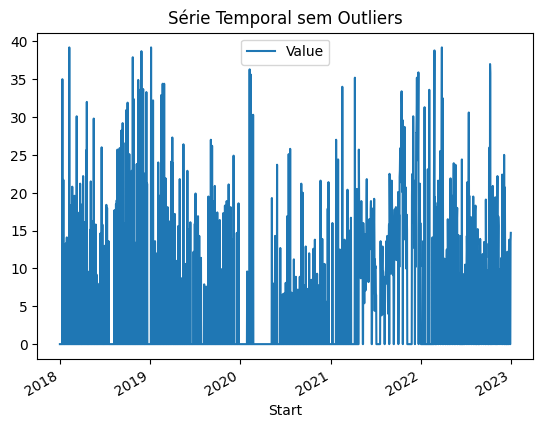

In [15]:
q_low = train['Value'].quantile(0.01)
q_high = train['Value'].quantile(0.99)
train_sem_outliers = train[(train['Value'] >= q_low) & (train['Value'] <= q_high)]
train_sem_outliers.plot()
plt.title('Série Temporal sem Outliers')
plt.show()

In [16]:
train_outliers = train[(train['Value'] < q_low) & (train['Value'] > q_high)]
train_outliers

,Value
Start,


- O dataset foi dividido em conjunto de treino e conjunto de teste, utilizando 80% das observações para treino e reservando os 20% mais recentes (correspondentes ao último ano) para teste.
- A partir da visualização gráfica da série temporal, associada ao cálculo de médias móveis e diferenciações, foi possível observar uma tendência ascendente a partir de 2021.
- Outro ponto importante observado foi a alta quantidade de valores iguais a zero, com 1.214 registros zerados no conjunto de treino, representando mais de 50% dos dados. Essa característica tem impacto direto na modelagem, podendo dificultar o aprendizado de padrões por parte dos algoritmos e prejudicar a capacidade de previsão. Essa questão foi considerada durante todo o desenvolvimento do projeto.

# 2. Componentes da série temporal

- O próximo passo foi identificar a presença de sazonalidades ou tendências cíclicas nos dados.
- Observou-se que os níveis de poluição tendiam a ser mais elevados durante os dias úteis, possivelmente devido ao aumento das atividades industriais e de transporte. Além disso, a partir do mês de abril, verificou-se um aumento gradual nos níveis de poluição.
- Foi também realizado um teste com Análise de Componentes Principais (PCA), utilizando 60 defasagens como variáveis, com o objetivo de capturar possíveis padrões sazonais mais complexos. No entanto, os resultados não indicaram uma sazonalidade clara ou predominante na série.
- Posteriormente, aplicou-se o método seasonal_decompose() para decompor a série temporal em seus componentes (tendência, sazonalidade e resíduo), utilizando a abordagem aditiva:
  - A decomposição reforçou que a tendência é a característica dominante da série, enquanto a sazonalidade é fraca ou inexistente.

<ipython-input-41-3918167252>:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  train['Value'].resample('M').mean().plot(figsize=(12,5), title='Média Mensal')


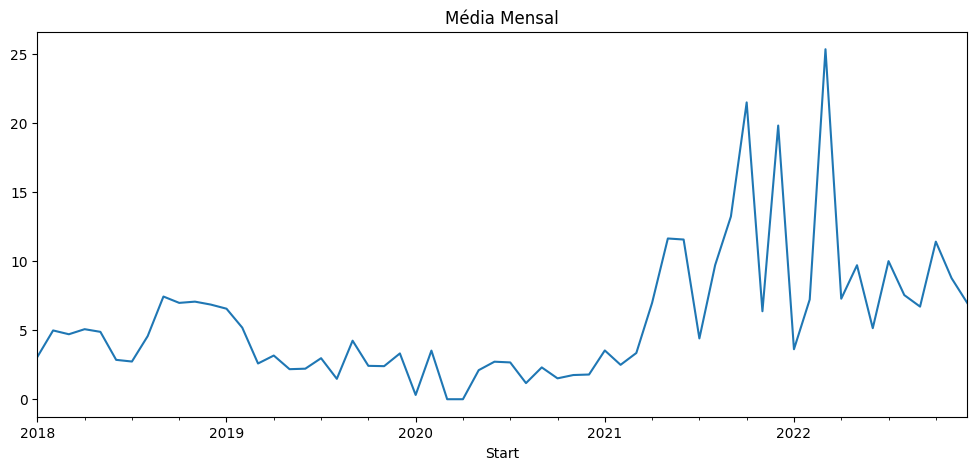

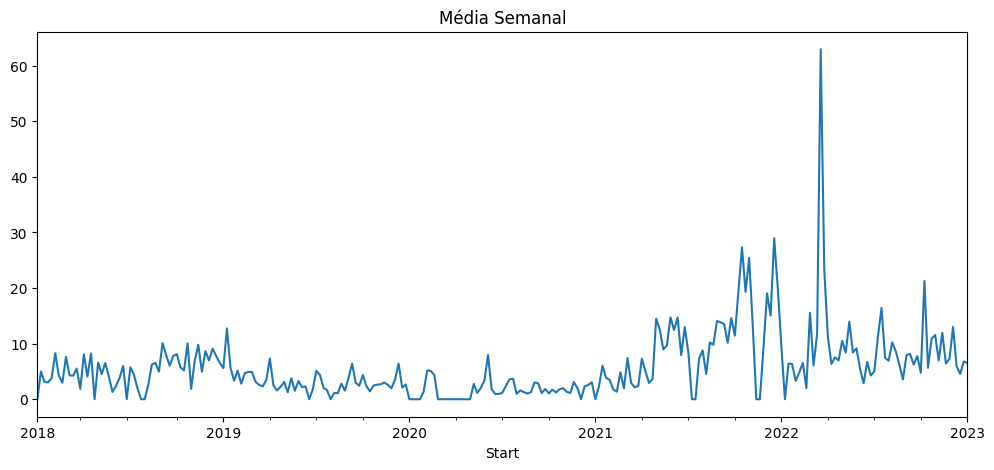

In [41]:
# Resample para médias mensais
train['Value'].resample('M').mean().plot(figsize=(12,5), title='Média Mensal')
plt.show()

# Resample para médias semanais
train['Value'].resample('W').mean().plot(figsize=(12,5), title='Média Semanal')
plt.show()

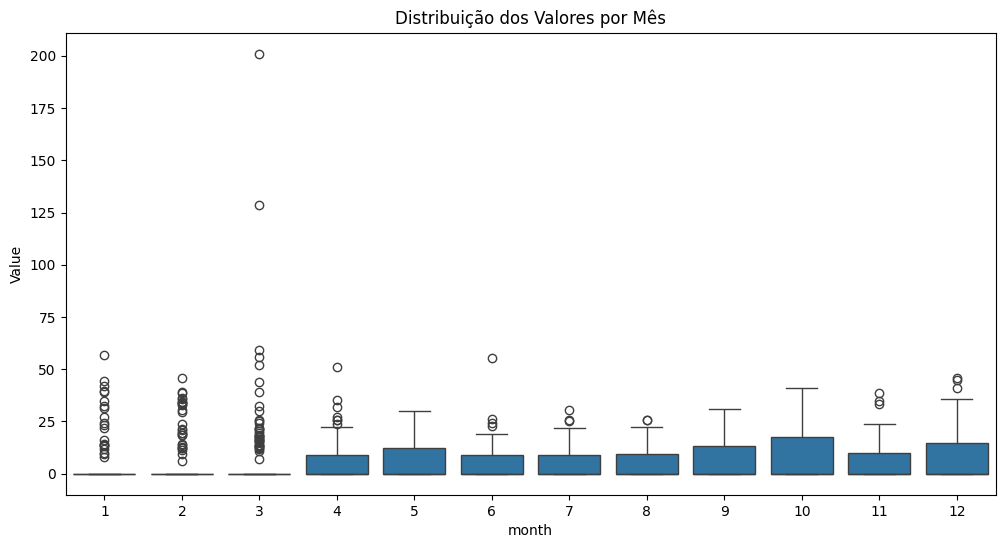

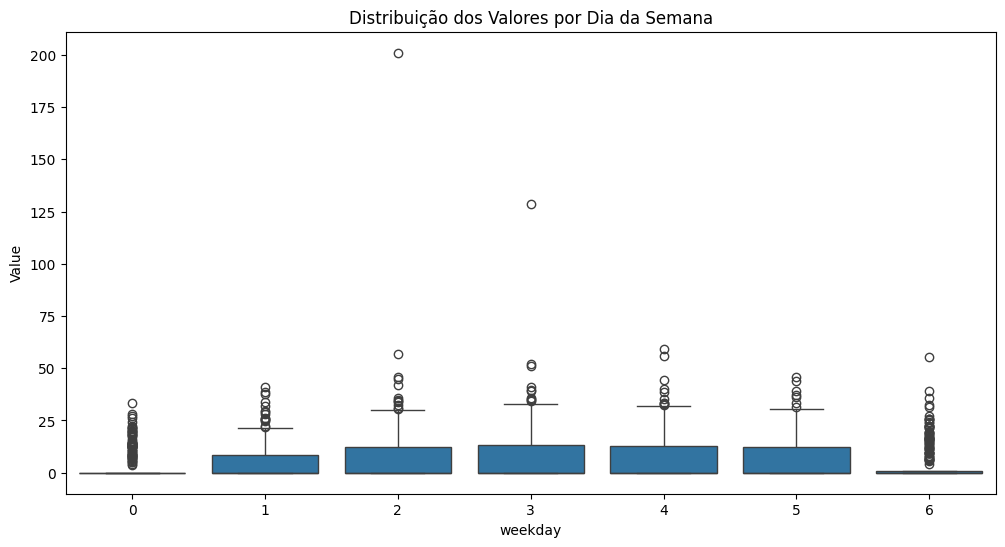

In [42]:
# Criar colunas auxiliares de mês e dia da semana
train['month'] = train.index.month
train['week'] = train.index.isocalendar().week
train['weekday'] = train.index.weekday

# Boxplot por mês
plt.figure(figsize=(12,6))
sns.boxplot(x='month', y='Value', data=train)
plt.title('Distribuição dos Valores por Mês')
plt.show()

# Boxplot por dia da semana (0=segunda, 6=domingo)
plt.figure(figsize=(12,6))
sns.boxplot(x='weekday', y='Value', data=train)
plt.title('Distribuição dos Valores por Dia da Semana')
plt.show()

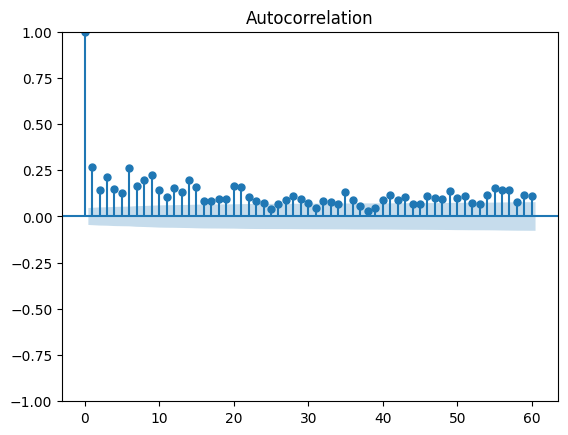

In [43]:
plot_acf(train['Value'].dropna(), lags=60)  # 60 lags = 2 meses em séries diárias
plt.show()

<Axes: xlabel='Start'>

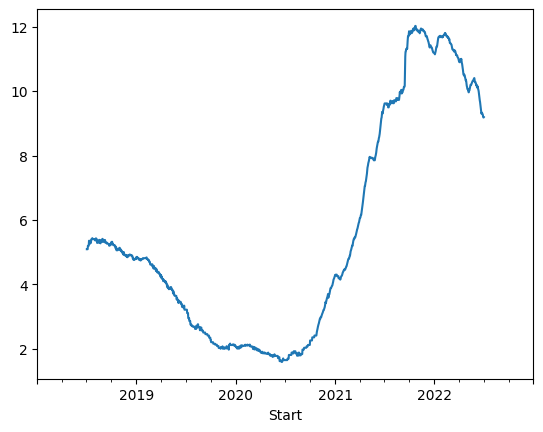

In [44]:
decompose_result = seasonal_decompose(train['Value'], model='additive', period=365)
decompose_result.trend.plot()

<Axes: xlabel='Start'>

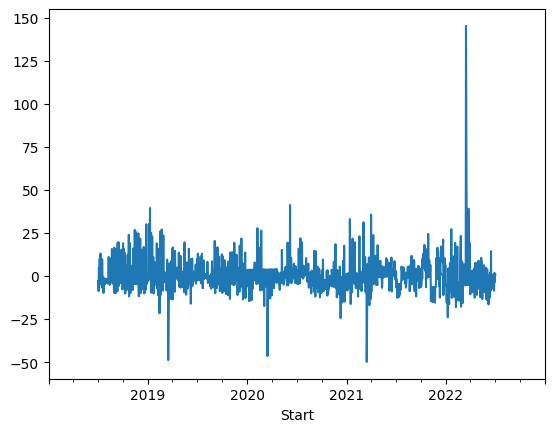

In [45]:
decompose_result.resid.plot()

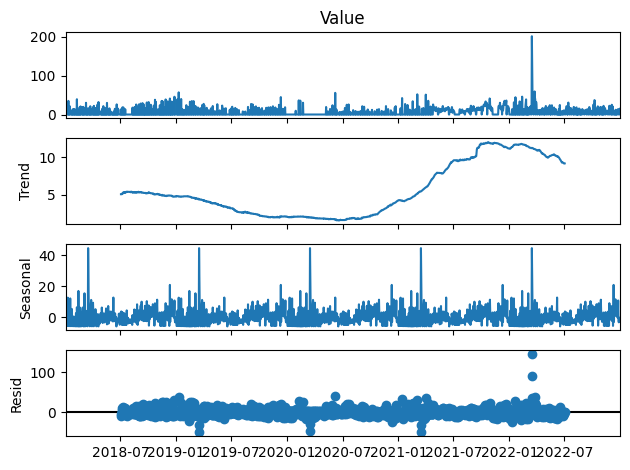

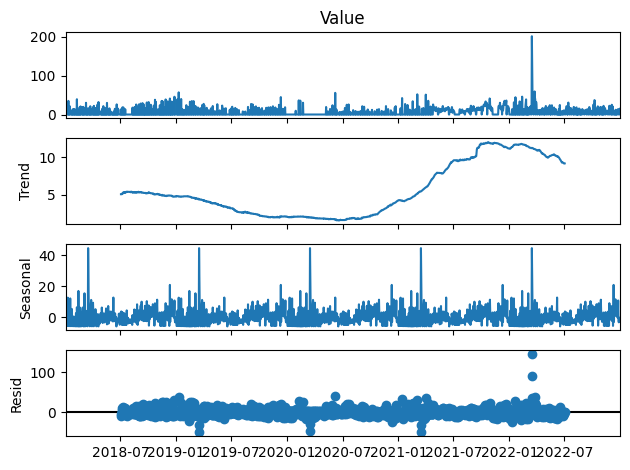

In [46]:
seasonal_decompose(train['Value'], model='additive', period=365).plot()

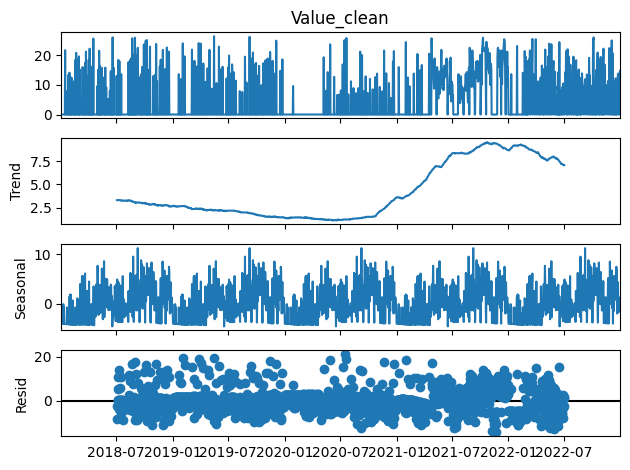

In [47]:
# Tratamento de outliers: método do IQR (Interquartile Range)
Q1 = train['Value'].quantile(0.25)
Q3 = train['Value'].quantile(0.75)
IQR = Q3 - Q1

# Definindo limites (pode ajustar o fator 1.5 conforme necessário)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Substituindo outliers por NaN (poderia também substituir por mediana)
train['Value_clean'] = train['Value'].where((train['Value'] >= lower_bound) & (train['Value'] <= upper_bound), np.nan)

# Se quiser preencher os NaNs por interpolação:
train['Value_clean'] = train['Value_clean'].interpolate()

# Decomposição após tratamento
result = seasonal_decompose(train['Value_clean'], model='additive', period=365)  # Ajuste o 'period' conforme necessário

# Plot
fig = result.plot()
plt.show()

# 3. Modelagem inicial - SARIMAX

- Como abordagem inicial, foi testado o modelo SARIMAX sobre a série original e sobre uma versão transformada da série, utilizando a transformação logarítmica (log1p) e diferenciação.
- Dado que a decomposição revelou uma tendência ascendente na série temporal, aplicou-se o teste de estacionariedade Augmented Dickey-Fuller (ADF) para confirmar se as transformações seriam suficientes para estabilizar a média da série.

<ipython-input-24-1081423593>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Value_log'] = np.log(train['Value'] + 1)
<ipython-input-24-1081423593>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Value_log'] = np.log(test['Value'] + 1)


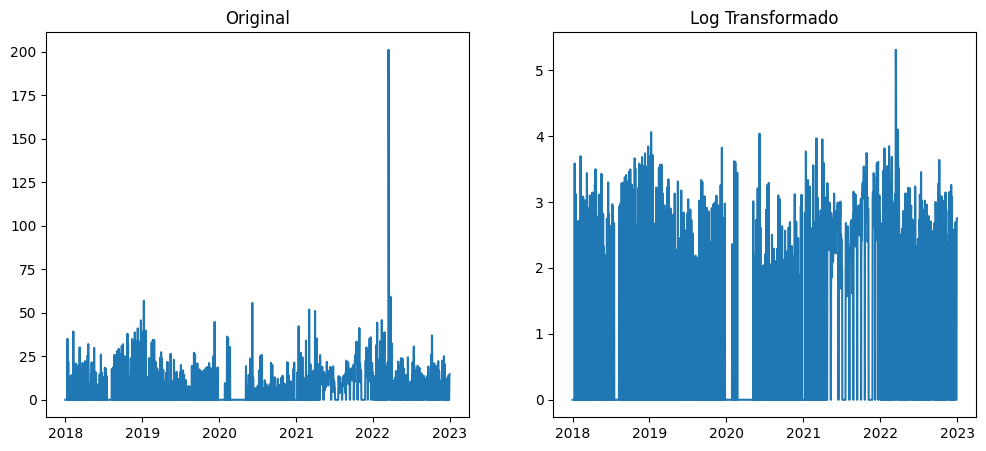

In [24]:
# Adiciona 1 para evitar log(0)
train['Value_log'] = np.log(train['Value'] + 1)
test['Value_log'] = np.log(test['Value'] + 1)

# Plot para comparação
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train['Value'])
plt.title('Original')

plt.subplot(1,2,2)
plt.plot(train['Value_log'])
plt.title('Log Transformado')
plt.show()

<ipython-input-25-3038209858>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Value_diff'] = train['Value_log'].diff()  # Lag 1
<ipython-input-25-3038209858>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Value_diff'] = test['Value_log'].diff()  # Lag 1


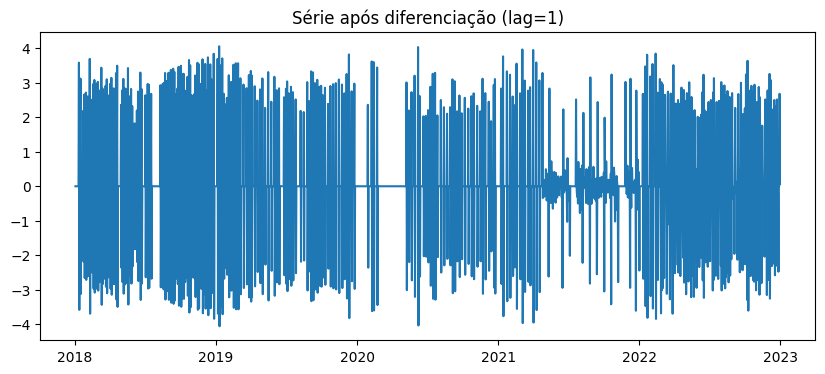

In [25]:
train['Value_diff'] = train['Value_log'].diff()  # Lag 1
train = train.dropna()
test['Value_diff'] = test['Value_log'].diff()  # Lag 1
test = test.dropna()

plt.figure(figsize=(10,4))
plt.plot(train['Value_diff'])
plt.title('Série após diferenciação (lag=1)')
plt.show()

In [26]:
result_diff = adfuller(train['Value_diff'])
print(f'ADF Statistic: {result_diff[0]}')
print(f'p-value: {result_diff[1]}')

ADF Statistic: -13.515017308103255
p-value: 2.805317415892212e-25


In [27]:
result = adfuller(train['Value'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -5.305180634061116
p-value: 5.34196188264964e-06


- Como o valor p em ambos os casos foi significativamente inferior a 0.05, rejeita-se a hipótese nula de não estacionariedade, indicando que as séries estavam estacionárias e adequadas para aplicação de modelos ARIMA/SARIMAX. Portanto, considerou-se que as séries estavam adequadamente estacionárias para modelagem.
- Na sequência, foi realizada uma busca pelos melhores hiperparâmetros de ordem (p, d, q), testando valores entre 1 e 4, tendo como critério de escolha a minimização do Akaike Information Criterion (AIC).

In [28]:
# funções de apoio para o modelo SARIMAX
def evaluate_model(y_true, y_pred, model):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    aic = model.aic

    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"AIC:  {aic:.4f}")

    return {'mae': mae, 'rmse': rmse, 'aic': aic}

def plot_predictions(y_true, pred_result):
    mean_pred = pred_result.predicted_mean
    conf_int = pred_result.conf_int()

    plt.figure(figsize=(14, 6))
    plt.plot(y_true.index, y_true, label='Real', color='black')
    plt.plot(mean_pred.index, mean_pred, label='Previsão', color='blue')
    plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='blue', alpha=0.2)
    plt.legend()
    plt.show()

In [29]:
p = q = range(0, 4)
pdq = list(itertools.product(p, [1], q))

aic_values = []

for order in pdq:
    try:
        model = sm.tsa.SARIMAX(train['Value'], order=order)
        results = model.fit(disp=False)
        aic_values.append((order, results.aic))
    except:
        continue

# Mostra as melhores opções:
sorted(aic_values, key=lambda x: x[1])[:5]

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

[((3, 1, 3), np.float64(13583.276564195912)),
 ((2, 1, 3), np.float64(13589.077444464081)),
 ((3, 1, 1), np.float64(13607.102234448845)),
 ((3, 1, 2), np.float64(13608.984511965173)),
 ((1, 1, 2), np.float64(13612.121770272299))]

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MAE:  9.0781
RMSE: 11.0742
AIC:  13556.9337


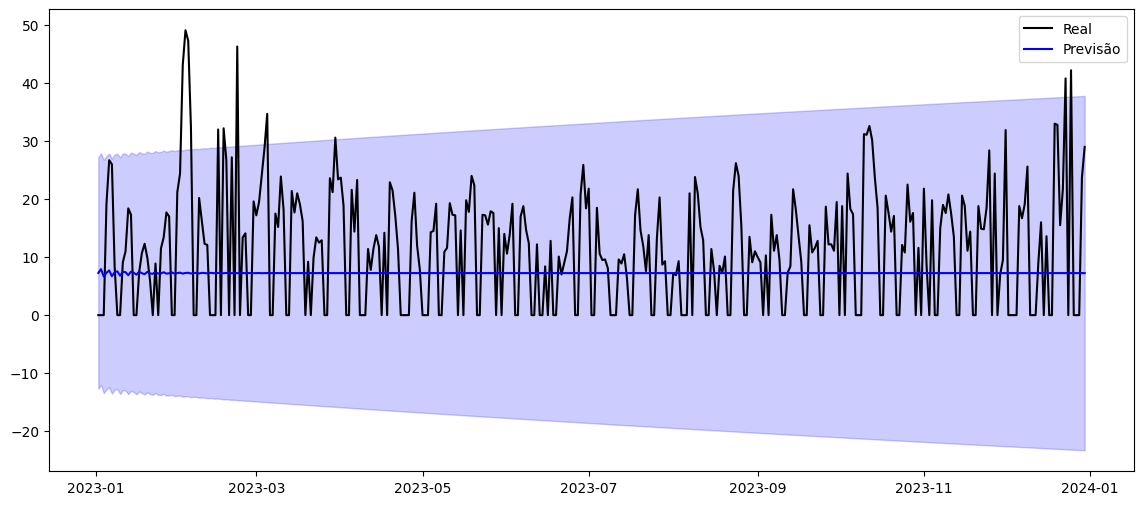

In [30]:
order = (3, 1, 3)  # <-- melhor AIC

model_original = sm.tsa.SARIMAX(train['Value'], order=order, enforce_stationarity=False, enforce_invertibility=False)
results_original = model_original.fit()

pred_original = results_original.get_prediction(start=test.index[0], end=test.index[-1], dynamic=False)
conf_int_original = pred_original.conf_int()

# Alinhar índices:
y_true = test['Value'].loc[pred_original.predicted_mean.index]

evaluate_model(y_true, pred_original.predicted_mean, results_original)
plot_predictions(y_true, pred_original)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MAE:  1.2073
RMSE: 1.7902
AIC:  5749.5418


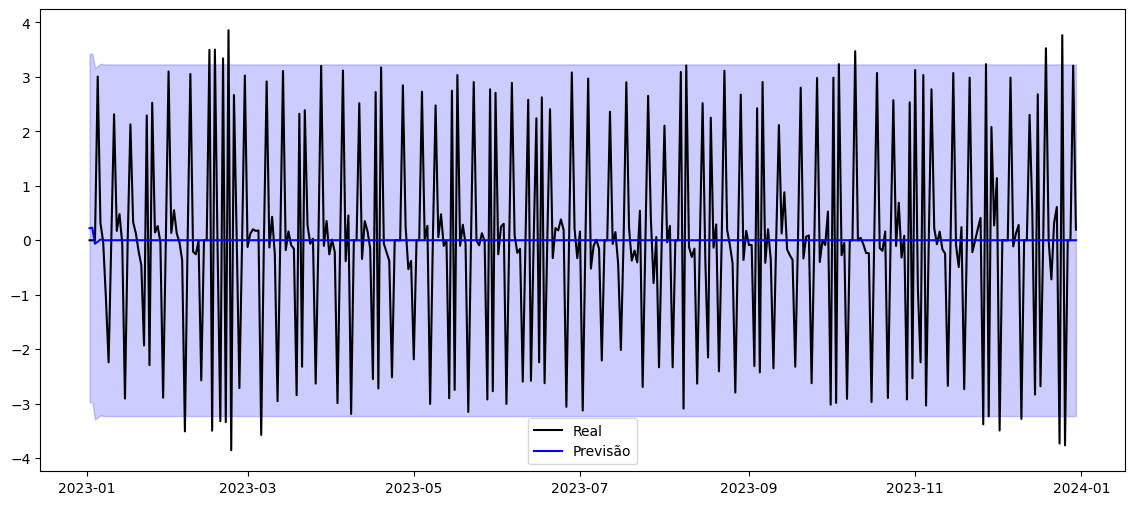

In [31]:
# Exemplo com o melhor modelo encontrado:
order = (3, 1, 3)  # <-- melhor AIC

model_original = sm.tsa.SARIMAX(train['Value_diff'], order=order, enforce_stationarity=False, enforce_invertibility=False)
results_original = model_original.fit()

pred_original = results_original.get_prediction(start=test.index[0], end=test.index[-1], dynamic=False)
conf_int_original = pred_original.conf_int()

# Alinhar índices:
y_true = test['Value_diff'].loc[pred_original.predicted_mean.index]

evaluate_model(y_true, pred_original.predicted_mean, results_original)
plot_predictions(y_true, pred_original)

- Apesar dos melhores resultados numéricos com a série transformada, a análise visual dos gráficos indicou que as previsões geradas eram excessivamente suavizadas e contínuas. Esse comportamento está relacionado à natureza do SARIMAX, que busca prever valores médios, o que não reflete bem as flutuações abruptas e a grande quantidade de zeros presentes na série.

# 4. Modelação com outros algoritmos de machine learning e feature engineering

- Foram geradas variáveis derivadas, incluindo lags, janelas móveis com agregações estatísticas e variáveis cíclicas baseadas no mês e no dia da semana e também indicações de feriados. Realizou-se um busca em grade para diferentes combinações de parâmetros para os modelos de machine learning (regressão linear, random Forest e xgboost).
- Para estes modelos, utilizamos os dados originais e com a transformação log1p, para poder comparar o desempenho dos modelos e também dos atributos em cada um dos cenários.

In [32]:
# Criando o conjunto de feriados de Portugal (Lisboa)
pt_holidays = holidays.country_holidays('PT', subdiv='Lisboa')

# Função para criar features
def build_some_features(df_, original, num_lags=1, num_diffs=0, weekday=False, month=False, rolling=[], holidays_flag=False):
    df_ = df_.copy()
    df_['Value'] = original  # Série alvo

    for i in range(1, num_lags + 1):
        df_['lagged_%s' % str(i)] = original.shift(i)

    for i in range(1, num_diffs + 1):
        df_['diff_%s' % str(i)] = original.diff(i)

    for stat in rolling:
        df_['rolling_%s' % str(stat)] = original.rolling('7D').aggregate(stat)

    if weekday:
        df_['sin_weekday'] = np.sin(2 * np.pi * df_.index.weekday / 7)
        df_['cos_weekday'] = np.cos(2 * np.pi * df_.index.weekday / 7)

    if month:
        df_['sin_month'] = np.sin(2 * np.pi * df_.index.month / 12)
        df_['cos_month'] = np.cos(2 * np.pi * df_.index.month / 12)

    if holidays_flag:
        df_['holidays'] = df_.index.to_series().apply(lambda date: 1 if date in pt_holidays else 0)

    return df_

def prepare_supervised(original, params):
    df = build_some_features(pd.DataFrame(index=original.index), original,
                             num_lags=params['num_lags'],
                             num_diffs=params['num_diffs'],
                             rolling=params['rolling'],
                             weekday=params['weekday'],
                             month=params['month'],
                             holidays_flag=params['holidays'])
    df.dropna(inplace=True)
    X = df.drop(columns=['Value'])
    y = df['Value']
    return X, y

# Configuração do grid de parâmetros
param_grid = {
    'num_lags': [1, 2, 3, 4, 5],
    'num_diffs': [0],
    'rolling': [[], ['mean','min','max','std']],
    'weekday': [True, False],
    'month': [True, False],
    'holidays': [True, False],
}
grid = list(ParameterGrid(param_grid))

model_list = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'LinearRegression': LinearRegression(),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

original_transf = np.log1p(df['Value'])
results = []

for model_name, model in model_list.items():
    print(f"Testando modelo: {model_name}")

    for params in grid:
        X, y = prepare_supervised(original_transf, params)

        if len(X) == 0 or len(y) == 0:
            continue

        tscv = TimeSeriesSplit(n_splits=3)
        maes_test = []
        rmses_test = []
        maes_train = []
        rmses_train = []

        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            if len(X_train) == 0 or len(X_test) == 0:
                continue

            model.fit(X_train, y_train)
            preds_test = model.predict(X_test)
            preds_train = model.predict(X_train)

            # Erros no teste
            rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
            mae_test = mean_absolute_error(y_test, preds_test)
            rmses_test.append(rmse_test)
            maes_test.append(mae_test)

            # Erros no treino
            rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
            mae_train = mean_absolute_error(y_train, preds_train)
            rmses_train.append(rmse_train)
            maes_train.append(mae_train)

        if len(maes_test) == 0 or len(rmses_test) == 0:
            continue

        results.append({
            'model': model_name,
            'params': params,
            'mae_test': np.mean(maes_test),
            'rmse_test': np.mean(rmses_test),
            'mae_train': np.mean(maes_train),
            'rmse_train': np.mean(rmses_train)
        })

# Exibir resultados
df_results = pd.DataFrame(results)
if df_results.empty:
    print("Nenhum resultado válido foi gerado.")
else:
    print(df_results.sort_values('mae_test'))

Testando modelo: RandomForest
Testando modelo: LinearRegression
Testando modelo: XGBoost
                model                                             params  \
139  LinearRegression  {'holidays': False, 'month': True, 'num_diffs'...   
159  LinearRegression  {'holidays': False, 'month': False, 'num_diffs...   
99   LinearRegression  {'holidays': True, 'month': True, 'num_diffs':...   
119  LinearRegression  {'holidays': True, 'month': False, 'num_diffs'...   
138  LinearRegression  {'holidays': False, 'month': True, 'num_diffs'...   
..                ...                                                ...   
102  LinearRegression  {'holidays': True, 'month': False, 'num_diffs'...   
123  LinearRegression  {'holidays': False, 'month': True, 'num_diffs'...   
83   LinearRegression  {'holidays': True, 'month': True, 'num_diffs':...   
143  LinearRegression  {'holidays': False, 'month': False, 'num_diffs...   
103  LinearRegression  {'holidays': True, 'month': False, 'num_diffs'...   

In [33]:
# Features do melhor modelo
df_results.params.iloc[139]

{'holidays': False,
 'month': True,
 'num_diffs': 0,
 'num_lags': 5,
 'rolling': ['mean', 'min', 'max', 'std'],
 'weekday': False}

In [34]:
original = df['Value']
results = []

for model_name, model in model_list.items():
    print(f"Testando modelo: {model_name}")

    for params in grid:
        X, y = prepare_supervised(original, params)

        if len(X) == 0 or len(y) == 0:
            continue

        tscv = TimeSeriesSplit(n_splits=3)
        maes_test = []
        rmses_test = []
        maes_train = []
        rmses_train = []

        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            if len(X_train) == 0 or len(X_test) == 0:
                continue

            model.fit(X_train, y_train)
            preds_test = model.predict(X_test)
            preds_train = model.predict(X_train)

            # Erros no teste
            rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
            mae_test = mean_absolute_error(y_test, preds_test)
            rmses_test.append(rmse_test)
            maes_test.append(mae_test)

            # Erros no treino
            rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
            mae_train = mean_absolute_error(y_train, preds_train)
            rmses_train.append(rmse_train)
            maes_train.append(mae_train)

        if len(maes_test) == 0 or len(rmses_test) == 0:
            continue

        results.append({
            'model': model_name,
            'params': params,
            'mae_test': np.mean(maes_test),
            'rmse_test': np.mean(rmses_test),
            'mae_train': np.mean(maes_train),
            'rmse_train': np.mean(rmses_train)
        })

# Exibir resultados
df_results = pd.DataFrame(results)
if df_results.empty:
    print("Nenhum resultado válido foi gerado.")
else:
    print(df_results.sort_values('mae_test'))

Testando modelo: RandomForest
Testando modelo: LinearRegression
Testando modelo: XGBoost
                model                                             params  \
139  LinearRegression  {'holidays': False, 'month': True, 'num_diffs'...   
159  LinearRegression  {'holidays': False, 'month': False, 'num_diffs...   
99   LinearRegression  {'holidays': True, 'month': True, 'num_diffs':...   
119  LinearRegression  {'holidays': True, 'month': False, 'num_diffs'...   
138  LinearRegression  {'holidays': False, 'month': True, 'num_diffs'...   
..                ...                                                ...   
82   LinearRegression  {'holidays': True, 'month': True, 'num_diffs':...   
143  LinearRegression  {'holidays': False, 'month': False, 'num_diffs...   
103  LinearRegression  {'holidays': True, 'month': False, 'num_diffs'...   
123  LinearRegression  {'holidays': False, 'month': True, 'num_diffs'...   
83   LinearRegression  {'holidays': True, 'month': True, 'num_diffs':...   

In [35]:
# Features do melhor modelo
df_results.iloc[139]

,139
model,LinearRegression
params,"{'holidays': False, 'month': True, 'num_diffs'..."
mae_test,4.058627
rmse_test,6.857948
mae_train,3.123827
rmse_train,5.634726


- O melhores modelos obtiveram as seguintes métricas e atributos, respetivamente:
  - Com dados transformados: MAE:  0.595081 | RMSE: 0.826212;
  - Com dados originais: MAE: 4.058627  | RMSE: 6.857948;
  - Atributos: ‘holidays': False |  'month': True | 'num_diffs': 0 |  'num_lags': 5 | 'rolling': ['mean', 'min', 'max', 'std'] | 'weekday': False};‘holidays': False |  'month': True | 'num_diffs': 0 |  'num_lags': 5 | 'rolling': ['mean', 'min', 'max', 'std'] | 'weekday': False};
- O facto de a mesma combinação de atributos ter sido selecionada nos dois cenários (transformado e original) é um bom indicativo de que essas features capturam bem as características relevantes da série. Considerando esse desempenho superior com log1p, decidimos utilizar apenas os dados transformados nas próximas etapas de modelagem.


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE:  0.7725
RMSE: 0.9373
AIC:  4513.8214


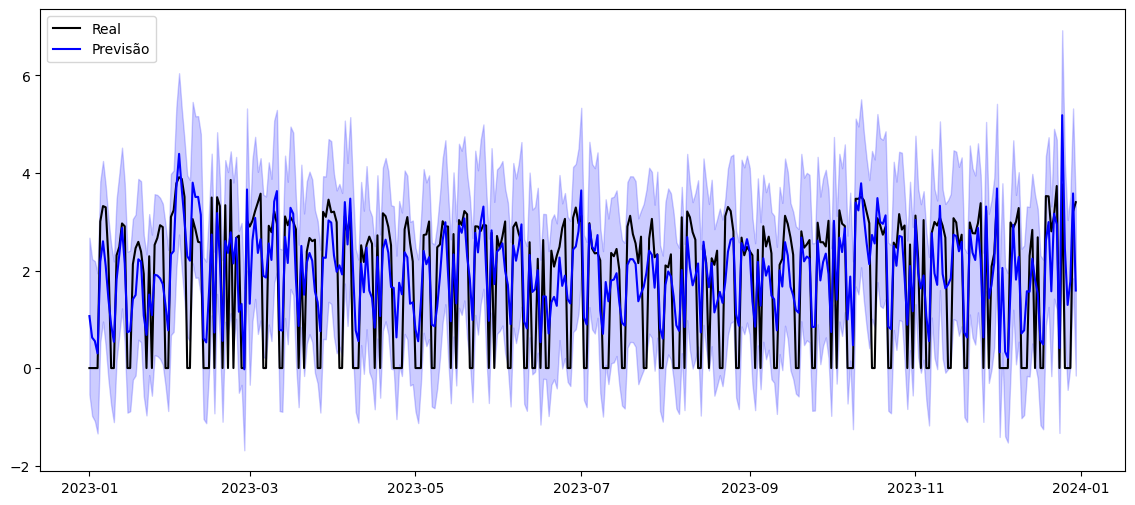

In [36]:
# Criar o dataset com as features que deram certo
df_features = build_some_features(pd.DataFrame(index=df.index), df['Value'],
                                  num_lags=5,
                                  rolling=['mean', 'min', 'max', 'std'],
                                  weekday=False, month=True, holidays_flag=False)

df_features.dropna(inplace=True)

y = np.log1p(df_features['Value'])
X = df_features.drop(columns=['Value'])

# Separação treino/teste
X_train, X_test = X.loc[:'2022-12-31'], X.loc['2023-01-01':]
y_train, y_test = y.loc[:'2022-12-31'], y.loc['2023-01-01':]

# SARIMAX com variáveis exógenas
model = SARIMAX(y_train,
                exog=X_train,
                order=(3,1,3),  # ou outro order encontrado antes, ou buscar novo
                enforce_stationarity=False,
                enforce_invertibility=False)
results = model.fit()

# Previsão
pred = results.get_prediction(start=X_test.index[0], end=X_test.index[-1], exog=X_test)
conf_int = pred.conf_int()

# Avaliação
pred = results.get_prediction(start=X_test.index[0], end=X_test.index[-1], exog=X_test)
evaluate_model(y_test, pred.predicted_mean, results)
plot_predictions(y_test, pred)

In [37]:
# Funções auxiliares para modelos de machine learning
def evaluate_model_ml(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'MAE: {mae:.4f} | RMSE: {rmse:.4f}')
    return mae, rmse

def plot_predictions_ml(y_true, y_pred):
    plt.figure(figsize=(14, 6))
    plt.plot(y_true.index, y_true, label='Real', color='black')
    plt.plot(y_pred.index, y_pred, label='Previsão', color='blue')
    plt.legend()
    plt.show()

MAE: 0.8072 | RMSE: 0.9668


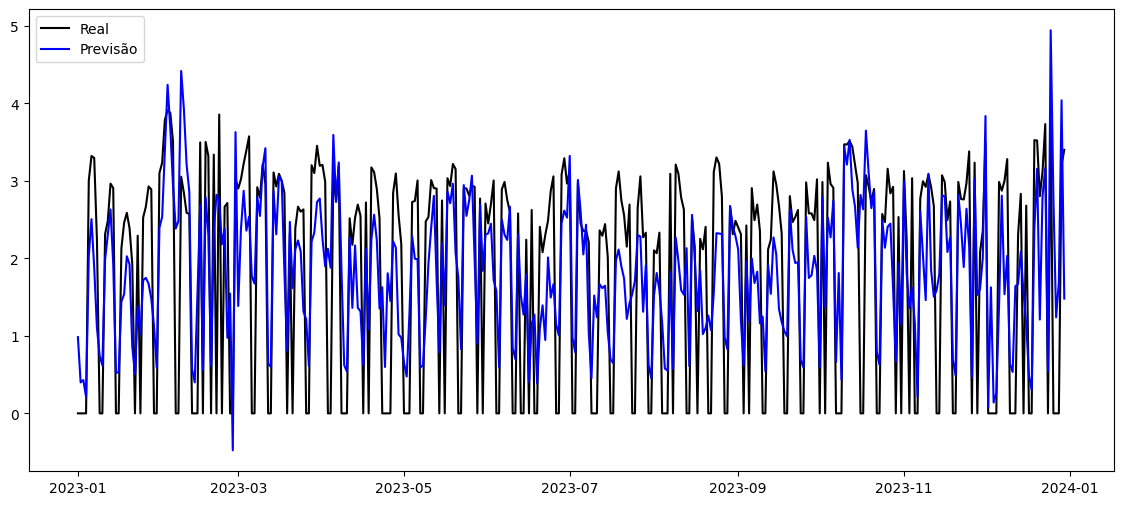

In [38]:
# Criar o dataset com as features que deram certo
df_features = build_some_features(pd.DataFrame(index=df.index), df['Value'],
                                  num_lags=5,
                                  rolling=['mean', 'min', 'max', 'std'],
                                  weekday=False, month=True, holidays_flag=False)

df_features.dropna(inplace=True)

y = np.log1p(df_features['Value'])
X = df_features.drop(columns=['Value'])

# Separação treino/teste
X_train, X_test = X.loc[:'2022-12-31'], X.loc['2023-01-01':]
y_train, y_test = y.loc[:'2022-12-31'], y.loc['2023-01-01':]

# Modelo LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = pd.Series(model.predict(X_test), index=X_test.index)

# Avaliação e gráfico
evaluate_model_ml(y_test, y_pred)
plot_predictions_ml(y_test, y_pred)

- Nos gráficos anteriores, quem mostram as previsões dos modelos SARIMAX e Regressão Linear com as variáveis derivadas (lags, janelas móveis e componentes sazonais), percebe-se um ajuste muito mais aderente ao comportamento real da série, acompanhando melhor os picos e vales dos valores observados.
Essa diferença visual, alinhada aos resultados das métricas (redução expressiva de MAE e RMSE), confirma que o uso de aprendizado de máquina, aliado à engenharia de atributos, oferece um ajuste mais adequado e eficiente para séries temporais com comportamentos irregulares.


# 5. Validação cruzada para séries temporais

- Para garantir a robustez e a generalização do modelo escolhido, utilizou-se validação cruzada específica para séries temporais, por meio da classe TimeSeriesSplit, da biblioteca scikit-learn. Diferentemente da validação cruzada tradicional, que embaralha os dados aleatoriamente, a validação cruzada temporal respeita a ordem cronológica da série, simulando cenários reais de previsão futura a partir de dados passados.
- Foi implementado um esquema de validação com 10 divisões sucessivas (n_splits=10), em que, a cada iteração, um novo bloco de dados mais recentes foi utilizado como conjunto de teste, enquanto os períodos anteriores serviram como treino. Essa abordagem permitiu avaliar a capacidade do modelo em se adaptar a mudanças ao longo do tempo.
- O modelo empregado na validação foi a Regressão Linear, combinado com o conjunto de features obtido na busca em grade. Para cada divisão, foi calculado o Erro Médio Absoluto (MAE), e os resultados foram analisados tanto de forma individual quanto agregada.


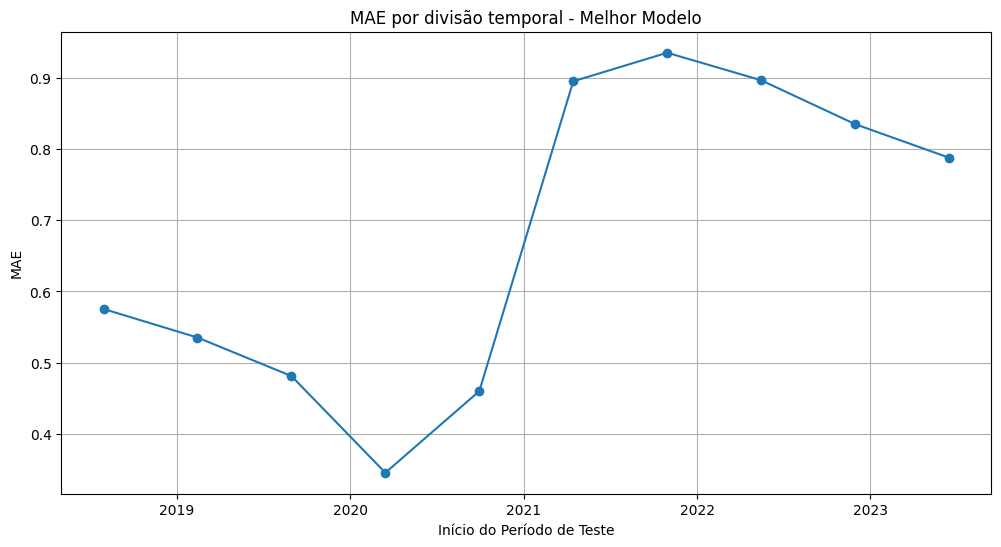

MAE médio nas 10 divisões: 0.6748


In [39]:
# Parâmetros do melhor modelo
best_model = LinearRegression()

# Dataset com as features que deram certo
df_features = build_some_features(pd.DataFrame(index=df.index), df['Value'],
                                  num_lags=5,
                                  rolling=['mean', 'min', 'max', 'std'],
                                  weekday=False, month=False, holidays_flag=False)
df_features.dropna(inplace=True)

y = np.log1p(df_features['Value'])
X = df_features.drop(columns=['Value'])

# Configuração da validação
n_splits = 10
tscv = TimeSeriesSplit(n_splits=n_splits)

mae_list = []
idx_list = []

for i, (tr, tt) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[tr], X.iloc[tt]
    y_train, y_test = y.iloc[tr], y.iloc[tt]

    best_model.fit(X_train, y_train)
    preds = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mae_list.append(mae)
    idx_list.append(X_test.index[0])

# Plot dos MAEs por período
plt.figure(figsize=(12, 6))
plt.plot(idx_list, mae_list, marker='o')
plt.title("MAE por divisão temporal - Melhor Modelo")
plt.xlabel("Início do Período de Teste")
plt.ylabel("MAE")
plt.grid(True)
plt.show()

# MAE médio geral
print(f"MAE médio nas {n_splits} divisões: {np.mean(mae_list):.4f}")

In [40]:
mae_list

[0.575326276769345,
 0.5351149356848888,
 0.48094885990923747,
 0.34491459026414895,
 0.45972263161436133,
 0.8956808760551164,
 0.935902358799761,
 0.8971780420644565,
 0.8354385509357336,
 0.7881743367636015]

- Além da análise quantitativa, também foi realizada uma avaliação visual dos resíduos e das previsões em cada divisão, de forma a identificar eventuais padrões sistemáticos de erro. O MAE médio obtido ao longo das 10 divisões foi de 0.6748, confirmando a consistência do modelo na tarefa de previsão. Essa estratégia de validação foi fundamental para avaliar a estabilidade do modelo ao longo de diferentes períodos temporais e garantir que o desempenho não estivesse condicionado a um único recorte da série.